<a href="https://colab.research.google.com/github/EstevahnAguilera/Data-Science-Projects/blob/main/Machine_Learning_in_Business.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project Description
You work for the OilyGiant Mining company. Your task is to find the best place for a new well.
### Steps to choose the location:
- Collect the oil well parameters in the selected region: oil quality and volume of reserves
- Build a model for predicting the volume of reserves in the new wells
- Pick the oil wells with the highest estimated values
- Pick the region with the highest total profit for the selected oil wells
## Additional Information:
You have data on oil samples from three regions. Paramaters of each oil well in the regian are already known. Build a model that will help to pick the region with the highest profit margin. Analyze potential profit and risks using the Bootstrapping technique.
### Data description:
- Geological exploration data for the three regions are stored in files:
    - geo_data_0.csv. download dataset
    - geo_data_1.csv. download dataset
    - geo_data_2.csv. download dataset
    - id — unique oil well identifier
    - f0, f1, f2 — three features of points (their specific meaning is unimportant, but the features themselves are significant)
    - product — volume of reserves in the oil well (thousand barrels).
### Conditions:
- Only linear regression is suitable for model training (the rest are not sufficiently predictable).
- When exploring the region, a study of 500 points is carried with picking the best 200 points for the profit calculation.
- The budget for development of 200 oil wells is 100 USD million.
- One barrel of raw materials brings 4.5 USD of revenue The revenue from one unit of product is 4,500 dollars (volume of reserves is in thousand barrels).
- After the risk evaluation, keep only the regions with the risk of losses lower than 2.5%. From the ones that fit the criteria, the region with the highest average profit should be selected.

# Project Instructions
### Step one: Download and prepare the data. Explain the procedure.
- First things first, you need to read the data.
- Next, you need to look at the data to see if there are any missing values that can affect the outcome of our model.
- We also need to look at our data to get a better understanding of what it means.

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

In [2]:
# Importing the .csv files from local computer
from google.colab import files
uploaded_0 = files.upload() # Geo_0
uploaded_1 = files.upload() # Geo_1
uploaded_2 = files.upload() # Geo_2

Saving geo_data_0.csv to geo_data_0.csv


Saving geo_data_1.csv to geo_data_1.csv


Saving geo_data_2.csv to geo_data_2.csv


In [3]:
# Reading the data
geo_0 = pd.read_csv('geo_data_0.csv')
geo_1 = pd.read_csv('geo_data_1.csv')
geo_2 = pd.read_csv('geo_data_2.csv')

In [4]:
# Looking at the data's info, shape and first 5 rows
def data_eval(dataframe):
    print(dataframe.info())
    print('This is the shape of the DataFrame:', dataframe.shape)
    print(dataframe.head(), '\n')

# Dataframes:
data_eval(geo_0)
data_eval(geo_1)
data_eval(geo_2)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       100000 non-null  object 
 1   f0       100000 non-null  float64
 2   f1       100000 non-null  float64
 3   f2       100000 non-null  float64
 4   product  100000 non-null  float64
dtypes: float64(4), object(1)
memory usage: 3.8+ MB
None
This is the shape of the DataFrame: (100000, 5)
      id        f0        f1        f2     product
0  txEyH  0.705745 -0.497823  1.221170  105.280062
1  2acmU  1.334711 -0.340164  4.365080   73.037750
2  409Wp  1.022732  0.151990  1.419926   85.265647
3  iJLyR -0.032172  0.139033  2.978566  168.620776
4  Xdl7t  1.988431  0.155413  4.751769  154.036647 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 5 columns):
 #   Column   Non-Null Count   Dtype  
---  ------   --------------   -----  
 0   id       1000

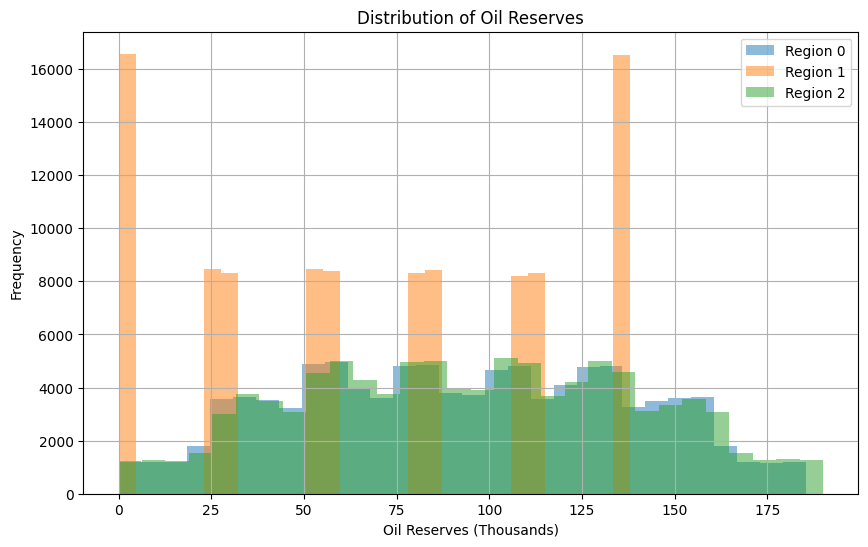

In [5]:
# Visual Representation of the target distribution for each Region

# All three regions target
region_0_product = geo_0['product']
region_1_product = geo_1['product']
region_2_product = geo_2['product']

# Plotting the histogram
plt.figure(figsize = (10, 6))
plt.hist(region_0_product, bins=30, alpha=0.5, label='Region 0')
plt.hist(region_1_product, bins=30, alpha=0.5, label='Region 1')
plt.hist(region_2_product, bins=30, alpha=0.5, label='Region 2')

# Adding labels and legend
plt.title('Distribution of Oil Reserves')
plt.xlabel('Oil Reserves (Thousands)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.show()

### Step 2: Train and test the model for each region:
- 2.1. Split the data into a training set and validation set at a ratio of 75:25.  

In [6]:
# Make sure to import the library needed for train_test_split

# Splitting the data into training and validation sets: 75:25
def split_data_sets(dataframe):
    # Also dropped 'id' as it is not needed for our model
    features = dataframe.drop(['product', 'id'], axis = 1)
    target = dataframe['product']

    features_train, features_valid, target_train, target_valid = train_test_split(
        features, target, test_size = 0.25, random_state = 12345)

    return features_train, features_valid, target_train, target_valid

# Testing the split on one dataframe
split_data_sets(geo_0)

(             f0        f1         f2
 27212  0.022450  0.951034   2.197333
 7866   1.766731  0.007835   6.436602
 62041  0.724514  0.666063   1.840177
 70185 -1.104181  0.255268   2.026156
 82230 -0.635263  0.747990   6.643327
 ...         ...       ...        ...
 4094   1.863680 -0.298123   1.621324
 85412 -1.162682 -0.014822   6.819941
 2177   0.862688 -0.403776   1.867662
 77285  0.846235 -0.489533   1.058786
 86498  2.019850  0.263887  11.497239
 
 [75000 rows x 3 columns],
              f0        f1        f2
 71751  0.948970 -0.057547  2.095727
 80493  0.992974  0.206671 -0.142278
 2655   1.199854 -0.563356 -1.852991
 53233  0.691422 -0.433347  0.564974
 91141  0.420772  0.972638  0.736190
 ...         ...       ...       ...
 12581  1.841106 -0.107678  2.585648
 18456  0.041859  0.489280  2.168001
 73035  0.376389  1.054298 -0.430104
 63834  1.071330 -0.470046  4.527099
 43558  1.726318 -0.077871  5.007083
 
 [25000 rows x 3 columns],
 27212    147.370612
 7866     147.630053


- 2.2. Train the model and make predictions for the validation set.
- 2.3. Save the predictions and correct answers for the validation set.
- 2.4. Print the average volumn of predicted reserves and model RMSE.  

In [7]:
# Make sure to import the needed library for LinearRegression & MSE

# Training the model and making predictions for the validation set:
def training_and_eval(dataframe):
    # Call split_data_sets function
    features_train, features_valid, target_train, target_valid = split_data_sets(dataframe)

    # Training my LinearRegression model
    model = LinearRegression()
    model.fit(features_train, target_train)

    # Making predictions
    predictions = model.predict(features_valid)

    # Calculating the average volume
    avg_reserves = predictions.mean()
    print('Average predictions: ', avg_reserves)

    # Calculating the RMSE
    rmse = (mean_squared_error(target_valid, predictions)) ** 0.5
    print('RMSE: ', rmse)

    return predictions, target_valid, rmse, avg_reserves

# Training a model for each dataframe:
predictions_0, target_valid_0, rmse_0, avg_reserves_0 = training_and_eval(geo_0)
predictions_1, target_valid_1, rmse_1, avg_reserves_1 = training_and_eval(geo_1)
predictions_2, target_valid_2, rmse_2, avg_reserves_2 = training_and_eval(geo_2)

Average predictions:  92.59256778438035
RMSE:  37.5794217150813
Average predictions:  68.728546895446
RMSE:  0.893099286775617
Average predictions:  94.96504596800489
RMSE:  40.02970873393434



- 2.5. Analyze the results.
    - Upon training three LinearRegression models using the three datasets, this is what I found:
        - Region 0: High average prediction (92.5) and a high RMSE (37.5).
        - Region 1: Lower average prediction (68.7) and an almost accurate model with a low RMSE (0.8).
        - Region 2: Highest average prediction (94.9) and the highest RMSE (40.0).
    - In terms of business at this moment:
        - Region 1 is the safest and most predictable even though it doesn't offer the highest average in return, it's RMSE is very low, meaning the $100 million investment has the minimalist risk.
        - Region 2 has the highest average which meaning that it has the highest potential when it comes to return, but due to a high RMSE, it is a big risk.
        - Region 0 is in the middle of the two, it has a high return as well, and the RMSE score is high which again can have a high return, but it is risky.  


### Step 3: Prepare for profit calculations:
- 3.1. Store all key values for calculations in separate variables.
- 3.2. Calculate the volume of reserves sufficient for developing a new well without losses. Compare the obtained value with the average volume of reserves in each region.

In [8]:
# Key values for calculations:
total_budget = 100000000
num_wells = 200
budget_per_well = 500000
revenue_per_thousand_barrels = 4500
risk_threshold = 0.025

# Break even volume
break_even = budget_per_well / revenue_per_thousand_barrels

# Creating a dataframe that contains the difference
regions = {
    "Region" : ["Region 0", "Region 1", "Region 2"],
    "Predicted Reserves": [avg_reserves_0, avg_reserves_1, avg_reserves_2],
    "RMSE": [rmse_0, rmse_1, rmse_2],
    "Break-Even Amount": [break_even, break_even, break_even],
    "Predicted Reserves - Break-Even Amount": [avg_reserves_0 - break_even, avg_reserves_1 - break_even, avg_reserves_2 - break_even]
}

Regions = pd.DataFrame(regions)

print(Regions)

     Region  Predicted Reserves       RMSE  Break-Even Amount  \
0  Region 0           92.592568  37.579422         111.111111   
1  Region 1           68.728547   0.893099         111.111111   
2  Region 2           94.965046  40.029709         111.111111   

   Predicted Reserves - Break-Even Amount  
0                              -18.518543  
1                              -42.382564  
2                              -16.146065  


- 3.3. Provide the findings about the preparation for profit calculation step.
    - Region 0:
        - High predicted reserve (92.59)
        - High prediction error (RMSE = 37.57)
        - Some potential and some risk
    - Region 1:
        - Lowest predicted reserves (68.72)
        - Very accurate (RMSE = 0.89)
        - Low risk, but unlikely to be profitable
    - Region 2:
        - Highest predicted reserves (94.96)
        - Highest prediction error (40.02)
        - High risk, but a high reward
    - Regions 0 and 2 have high risks, but they may exceed the break even point.
        -  Region 0: 92.59 ± 37.57 = range of approximately 55.02 to 130.16 thousand barrels
        -  Region 2: 94.96 ± 40.02 = range of approximately 54.94 to 134.98 thousand barrels

### Step 4: Writing a function to calculate profit from a set of selected oil wells and model predictions:
- 4.1. Pick the wells with the highest values of predictions.
- 4.2. Summarize the target volume of reserves in accordance with these predictions.

In [9]:
# Profit function
def profit(predictions, target, revenue_per_thousand_barrels, budget_per_well, num_wells):
    # Top 200 predictions and the targets that correspond to these predictions
    top_200_predict = predictions.argsort()[-200:]
    top_200_targets = target.iloc[top_200_predict]

    # Calculating the profit

    # Revenue:
    top_200_targets_revenue = top_200_targets.sum() * revenue_per_thousand_barrels

    # Cost:
    top_200_targets_cost = num_wells  * budget_per_well

    # Profit
    top_200_targets_profit = top_200_targets_revenue - top_200_targets_cost

    return top_200_targets_profit


# Finding the Regions Profit
geo_0_profit = profit(predictions_0, target_valid_0, revenue_per_thousand_barrels, budget_per_well, num_wells)
geo_1_profit = profit(predictions_1, target_valid_1, revenue_per_thousand_barrels, budget_per_well, num_wells)
geo_2_profit = profit(predictions_2, target_valid_2, revenue_per_thousand_barrels, budget_per_well, num_wells)

print("This is Region 0's profit: ", geo_0_profit)
print("This is Region 1's profit: ", geo_1_profit)
print("This is Region 2's profit: ", geo_2_profit)

This is Region 0's profit:  33208260.43139851
This is Region 1's profit:  24150866.966815114
This is Region 2's profit:  27103499.635998324


- 4.3. Provide findings: suggest a region for oil wells' development and justify the choice. Calculate the profit for the obtained volume of reserves.
    - Based purely on the profit calculations, the region that I would suggest would be Region 0 as it has the most profit.

### Step 5: Calculate risks and profit for each region:
- 5.1. Use the bootstrapping technique with 1000 samples to find the distribution of profit.
- 5.2. Find average profit, 95% confidence interval and risk of losses. Loss is negative profit, calculate it as a probability and then express as a percentage.

In [10]:
# Make sure to import the necessary libraries

# Using bootstrapping with 1000 samples to find distribution of profit
def bootstrap_profit(predictions, targets, n_samples=1000):
    # Randomstate
    state = np.random.RandomState(12345)

    # Array for my profits
    profits = []

    # Loop through 1000 samples
    for i in range(n_samples):
        # Sample indicies with replacement, the size should be 500
        indices = state.choice(len(predictions), size = 500, replace = True)

        # Get bootstrap samples using the indicies
        bootstrap_predictions = predictions[indices]
        bootstrap_targets = targets.iloc[indices]

        # Calculating profit for the bootstrap sample
        sample_profit = profit(bootstrap_predictions, bootstrap_targets, revenue_per_thousand_barrels, budget_per_well, num_wells)

        # Add to my array
        profits.append(sample_profit)

    return np.array(profits)

# Running the Bootstrap function for each region
profits_0 = bootstrap_profit(predictions_0, target_valid_0)
profits_1 = bootstrap_profit(predictions_1, target_valid_1)
profits_2 = bootstrap_profit(predictions_2, target_valid_2)

# Average profits
avg_region_0_profit = np.mean(profits_0)
avg_region_1_profit = np.mean(profits_1)
avg_region_2_profit = np.mean(profits_2)

print("This is the average profit for Region 0: ", avg_region_0_profit)
print("This is the average profit for Region 1: ", avg_region_1_profit)
print("This is the average profit for Region 2: ", avg_region_2_profit)

# Confidence interval for 95%
region_0_confidence_interval = np.quantile(profits_0, [0.025,0.975])
region_1_confidence_interval = np.quantile(profits_1, [0.025,0.975])
region_2_confidence_interval = np.quantile(profits_2, [0.025,0.975])

print("This is the confidence interval for Region 0: ", region_0_confidence_interval)
print("This is the confidence interval for Region 1: ", region_1_confidence_interval)
print("This is the confidence interval for Region 2: ", region_2_confidence_interval)

# Risk of losses
region_0_risk_of_loss = (profits_0 < 0).mean() * 100
region_1_risk_of_loss = (profits_1 < 0).mean() * 100
region_2_risk_of_loss = (profits_2 < 0).mean() * 100

print("This is the risk of losses for Region 0: ", region_0_risk_of_loss)
print("This is the risk of losses for Region 1: ", region_1_risk_of_loss)
print("This is the risk of losses for Region 2: ", region_2_risk_of_loss)

This is the average profit for Region 0:  3961649.848023711
This is the average profit for Region 1:  4560451.057866606
This is the average profit for Region 2:  4044038.665683569
This is the confidence interval for Region 0:  [-1112155.45890496  9097669.41553424]
This is the confidence interval for Region 1:  [ 338205.09398986 8522894.53866033]
This is the confidence interval for Region 2:  [-1633504.133956  9503595.749238]
This is the risk of losses for Region 0:  6.9
This is the risk of losses for Region 1:  1.5
This is the risk of losses for Region 2:  7.6


- 5.3. Provide findings: suggest a region for development of oil wells and justify the choice.
    - Region 1 has the highest average profit and a strong confidence interval. This mean that profits are consistently above 300 thousand with potential to exceed 8.5 million.
    - Region 1 also has a risk of loss that is lower than 2.5% meaning that its a safe investment.
    - Region 0 and Region 2 have a higher risk of loss that is above the 2.5% and their confidence intervals are below 0 meaning that there is a chance of financial loss.